---
jupyter: ir
---


In [30]:
# Instalação de pacotes necessários
pkgs <- c(
  "tidymodels",
  'glmnet',
  "rstanarm"
)

instalar <- pkgs[!pkgs %in% installed.packages()[, "Package"]]

if (length(instalar) > 0) {
  install.packages(instalar)
}

In [31]:
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(glmnet)
library(dplyr)

In [32]:
#
set.seed(42)

In [33]:
loan <- read_csv("../data/Loan/loan_approval_dataset.csv") |>
  clean_names()

Rows: 4269 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): education, self_employed, loan_status
dbl (10): loan_id, no_of_dependents, income_annum, loan_amount, loan_term, c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
loan <- loan %>%
  rename(
    num_dependentes      = no_of_dependents,
    escolaridade         = education,
    autonomo             = self_employed,
    renda_anual          = income_annum,
    valor_emprestimo     = loan_amount,
    prazo_anos           = loan_term,
    score_credito        = cibil_score,
    ativos_residenciais  = residential_assets_value,
    ativos_comerciais    = commercial_assets_value,
    ativos_luxo          = luxury_assets_value,
    ativos_bancarios     = bank_asset_value,
    status    = status
)


loan$status <- ifelse(
  loan$status %in% c("Approved", 1, "1"),
  1, 0
)
loan$status <- as.factor(loan$status)

In [36]:
vars_numericas <- c(
  "renda_anual",
  "valor_emprestimo",
  "prazo_anos",
  "score_credito",
  "ativos_residenciais",
  "ativos_comerciais",
  "ativos_luxo",
  "ativos_bancarios"
)

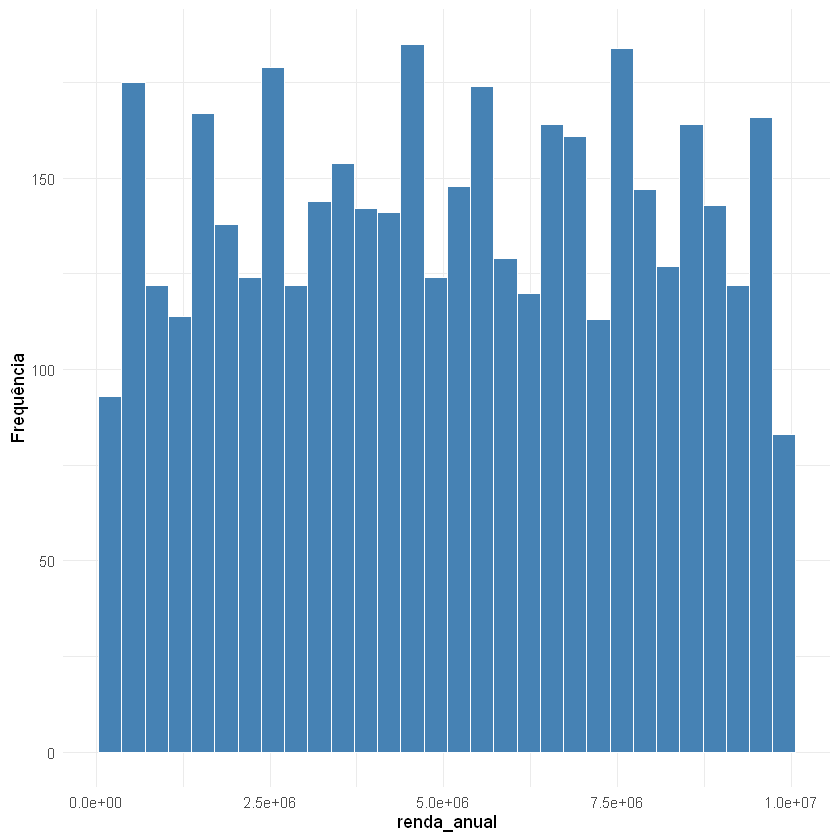

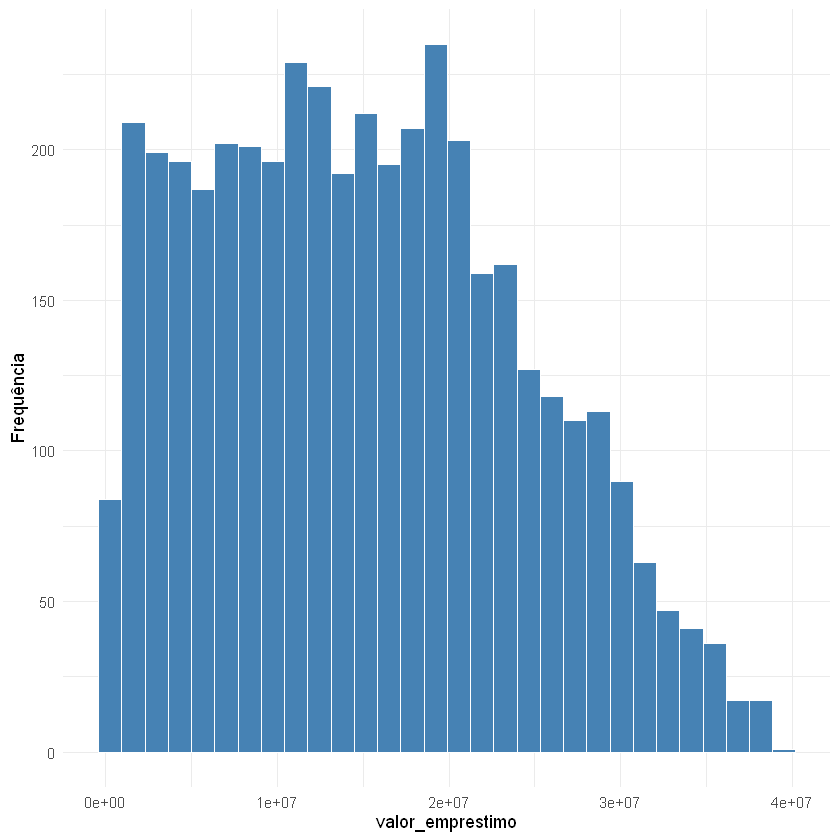

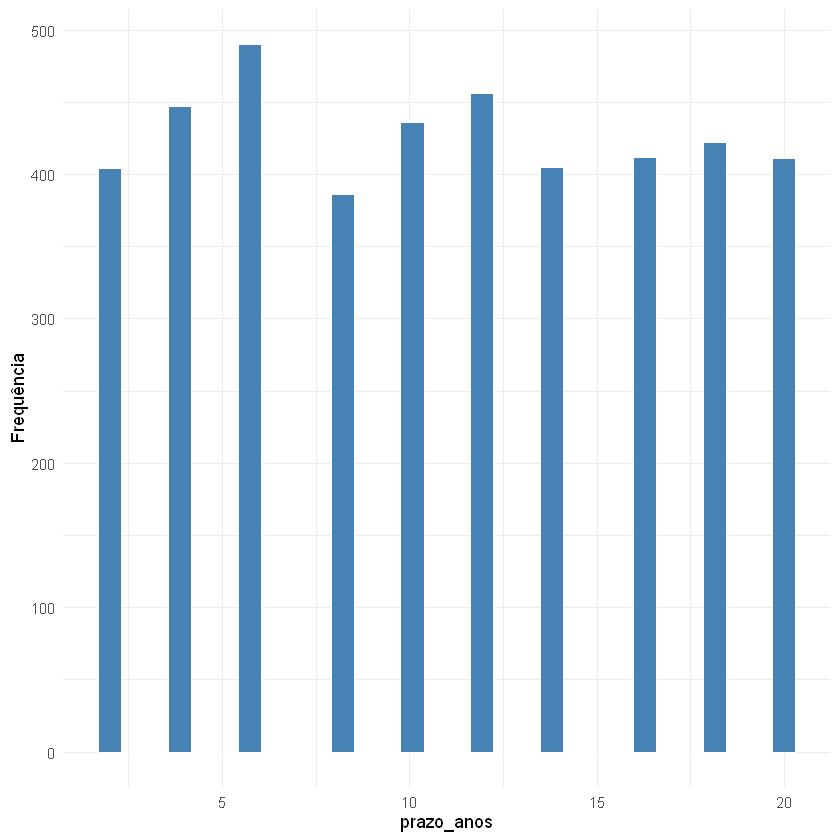

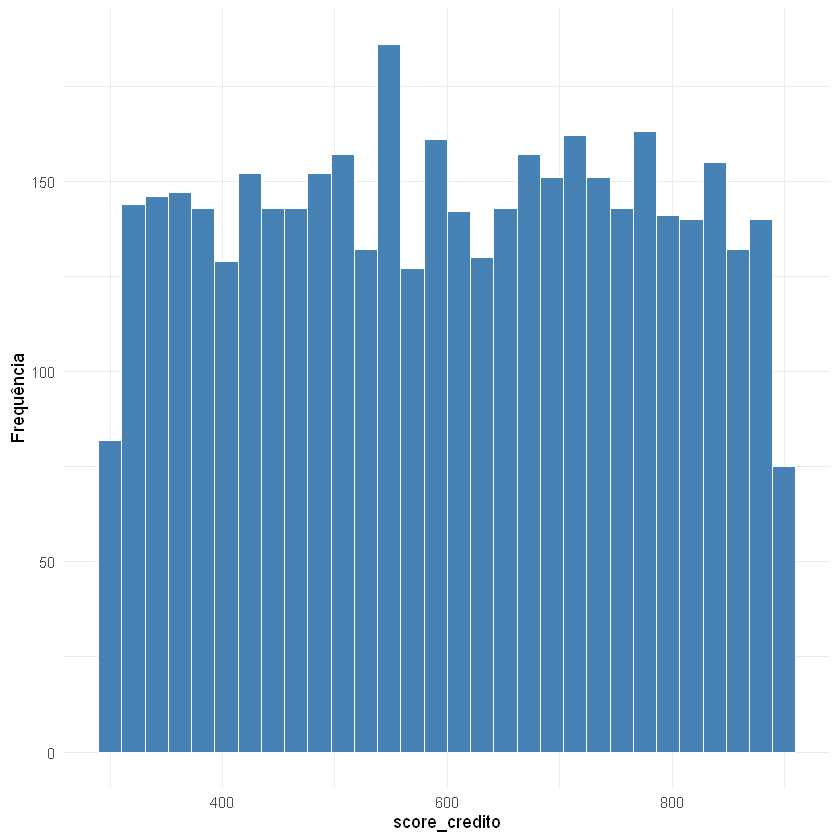

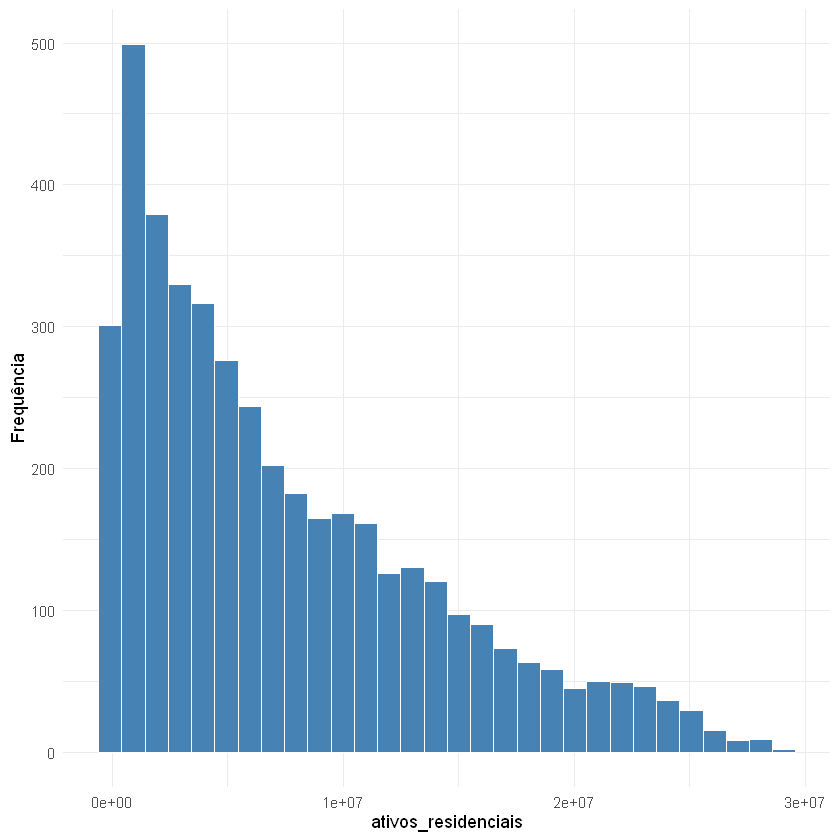

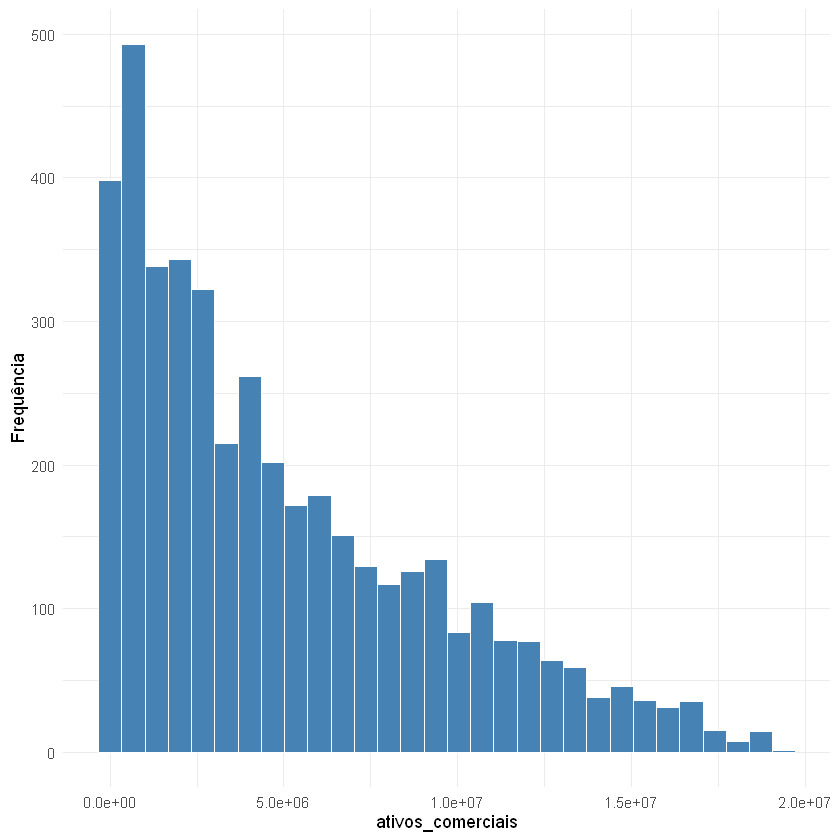

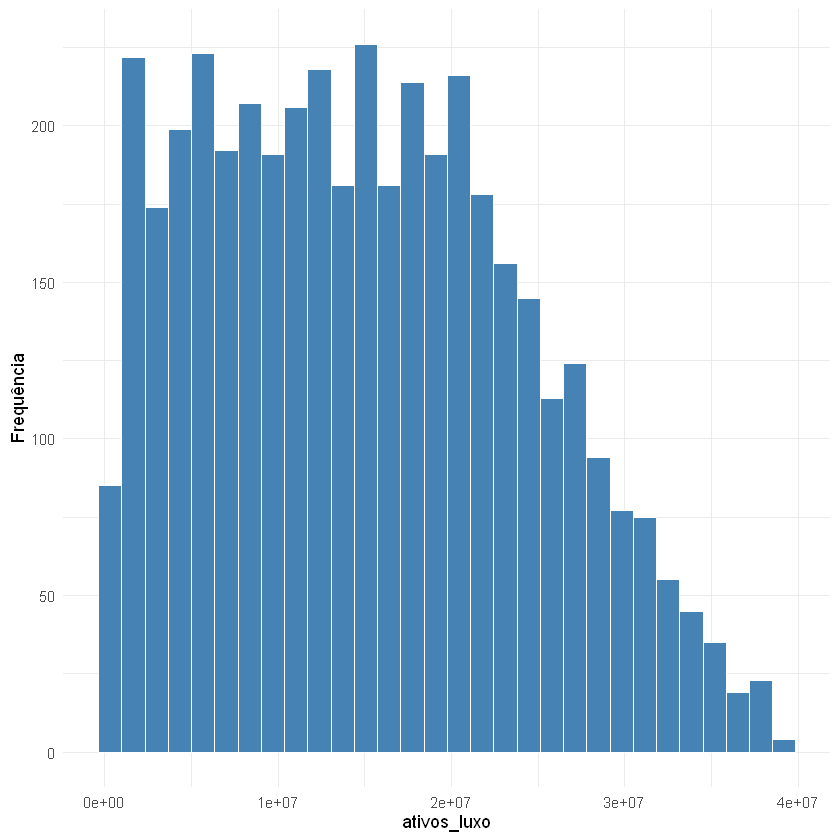

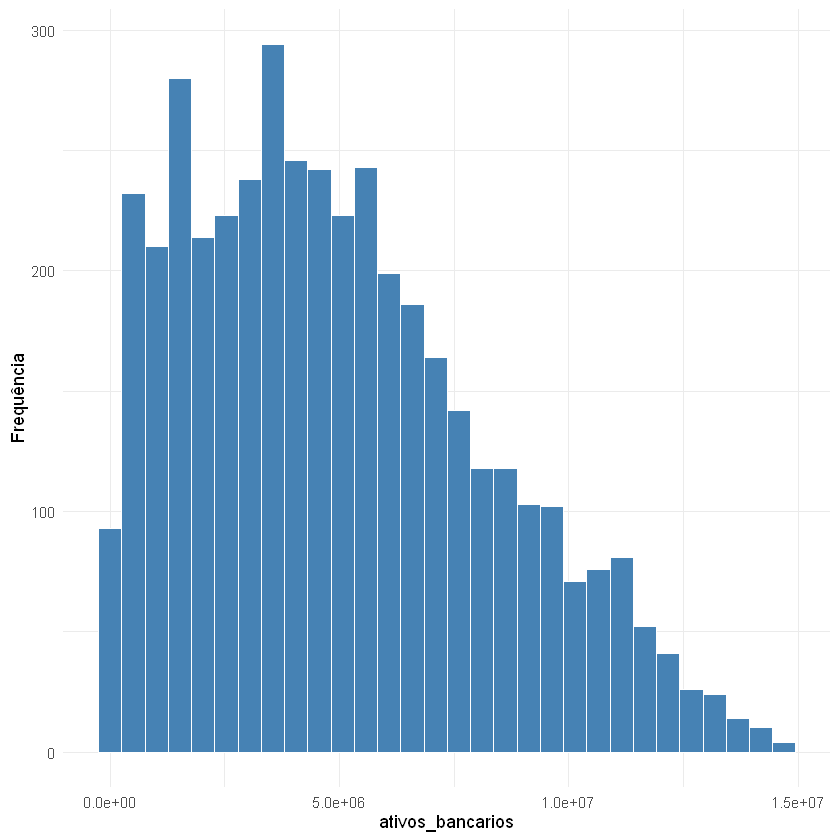

In [37]:
for (v in vars_numericas) {
  
  p <- ggplot(loan, aes(x = .data[[v]])) +
    geom_histogram(bins = 30, fill = "steelblue", color = "white") +
    theme_minimal() +
    labs(
      x = v,
      y = "Frequência"
    )
  
  print(p)
}

---------------------

In [38]:
#preprocessamento
loan <- janitor::clean_names(loan)

loan <- loan |>
  dplyr::filter(ativos_bancarios >= 0)

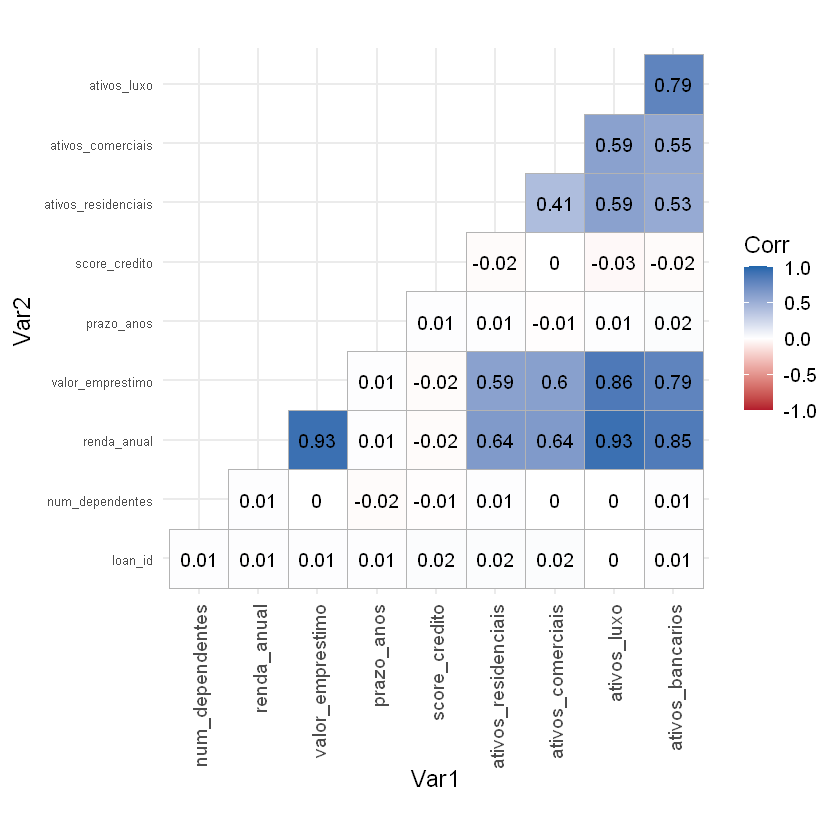

In [39]:
loan_num <- loan |>
  dplyr::select(where(is.numeric))

cor_matrix <- cor(
  loan_num,
  use = "complete.obs",
  method = "pearson"
)

ggcorrplot(
  cor_matrix,
  type = "lower",
  lab = TRUE,
  lab_size = 4,
  colors = c("#b2182b", "white", "#2166ac"),
  outline.col = "gray70"
) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5
    ),
    axis.text.y = element_text(size = 8)
  )

In [40]:
vars_categoricas <- c(
  "escolaridade",
  "autonomo"
)

# One-Hot Encoding
loan_encoded <- loan %>%
  mutate(
    escolaridade = factor(escolaridade),
    autonomo = factor(autonomo)
  ) %>%
  fastDummies::dummy_cols(
    select_columns = vars_categoricas,
    remove_selected_columns = TRUE,
    remove_first_dummy = TRUE
  )


In [43]:
#remodendo loan id
split <- initial_split(
  loan_encoded,
  prop   = 0.75,
  strata = status
)

train_data <- training(split)
test_data  <- testing(split)

In [45]:
count(train_data, status)
count(test_data, status)

status,n
<fct>,<int>
0,1209
1,1992


status,n
<fct>,<int>
0,404
1,664


para o frequentista
- Modelo geral (tudo) OK
- Modelo apenas com score Ok
- Modelo sem score ok
- Modelo com remoção das feats correlacionadas ok
- Modelo com PCA
- Modelo com regularização para selecionar feats (glmnet) ok

In [46]:
rec_lasso <- recipe(status ~ ., data = train_data) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

logit_lasso_spec <- logistic_reg(
  penalty = tune(),
  mixture = 1        # LASSO puro
) %>%
  set_engine("glmnet")

wf_lasso <- workflow() %>%
  add_recipe(rec_lasso) %>%
  add_model(logit_lasso_spec)


folds <- vfold_cv(train_data, v = 5)

grid_lambda <- grid_regular(penalty(), levels = 50)

lasso_res <- tune_grid(
  wf_lasso,
  resamples = folds,
  grid = grid_lambda,
  metrics = metric_set(roc_auc)
)  
best_lambda <- select_best(lasso_res, metric = "roc_auc")
best_lambda

penalty,.config
<dbl>,<chr>
0.001389495,pre0_mod36_post0


In [47]:
final_lasso_wf <- finalize_workflow(
  wf_lasso,
  best_lambda
)

final_lasso_fit <- fit(
  final_lasso_wf,
  data = train_data
)

lasso_coefs <- final_lasso_fit %>%
  extract_fit_parsnip() %>%
  tidy()

vars_selected <- lasso_coefs %>%
  filter(term != "(Intercept)") %>%
  filter(estimate != 0) %>%
  mutate(abs_est = abs(estimate))
vars_importance <- vars_selected %>%
  mutate(importance = abs_est / sum(abs_est)) %>%
  select(variable = term, importance) %>%
  arrange(desc(importance))

vars_importance

variable,importance
<chr>,<dbl>
score_credito,0.5939328660
valor_emprestimo,0.1382232651
renda_anual,0.1346883746
prazo_anos,0.1135822957
escolaridade_Not Graduate,0.0085207954
ativos_residenciais,0.0040031169
num_dependentes,0.0034763922
autonomo_Yes,0.0030803176
ativos_comerciais,0.0004925765


In [73]:
not_best_vars <- vars_importance %>%
  dplyr::filter(importance < 0.015) %>%
  dplyr::pull(variable)

In [ ]:
#modelo geral
rec_all <- recipe(status ~ ., data = train_data)

# score only
rec_score_only <- recipe(
  status ~ score_credito,
  data = train_data
)

#resultado da regularização
rec_feat_select <- recipe(
  status ~ .,
  data = train_data
) |>
  step_normalize(all_numeric_predictors())

#no score
rec_no_score <- recipe(
  status ~ .,
  data = train_data
) |>
  step_rm(score_credito)

# Removendo alta correlação
rec_no_corr <- recipe(
  status ~ .,
  data = train_data
) |>
  step_corr(all_numeric_predictors(), threshold = 0.75)



#com pca
rec_pca <- recipe(
  status ~ .,
  data = train_data
) |>
  step_normalize(all_numeric_predictors()) |>
  step_pca(
    all_numeric_predictors(),
    threshold = 0.95
  )

In [75]:
log_spec <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")

In [76]:
wf_logit <- workflow_set(
  preproc = list(
    all_features = rec_all,
    score_only   = rec_score_only,
    no_score     = rec_no_score,
    no_corr      = rec_no_corr,
    feat_select  = rec_feat_select
  ),
  models = list(
    logit = log_spec
  )
)

wf_pca <- workflow_set(
  preproc = list(
    pca = rec_pca
  ),
  models = list(
    logit = log_spec
  )
)

In [77]:
wf_set <- rbind(
  wf_logit,
  wf_pca
)

In [78]:
wf_fitted <- wf_set %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data)
    )
  )

In [79]:
wf_preds <- wf_fitted %>%
  mutate(
    preds = purrr::map(
      fit,
      ~ predict(.x, test_data, type = "prob") %>%
          bind_cols(
            predict(.x, test_data, type = "class"),
            test_data %>% select(status)
          )
    )
  )

In [80]:
fits <- wf_set %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data)
    )
  )

In [81]:
library(dplyr)
library(purrr)
library(yardstick)

preds <- fits %>%
  mutate(
    preds = purrr::map(
      fit,
      ~{
        prob_tbl <- predict(.x, test_data, type = "prob")

        tibble(
          truth = test_data$status,
          class = predict(.x, test_data, type = "class")$.pred_class,
          prob  = prob_tbl$.pred_1
        )
      }
    )
  ) %>%
  select(wflow_id, preds)

In [82]:
preds <- preds %>%
  tidyr::unnest(preds)

In [83]:
metrics_table <- preds %>%
  group_by(wflow_id) %>%
  summarise(

    # 📌 classificação geral
    accuracy = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    # 📌 ranking / separação
    roc_auc = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    # 📌 sensibilidade / especificidade
    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    # 📌 custo de erro (crédito)
    precision = precision_vec(truth, class),
    npv = npv_vec(truth, class),

    # 📌 equilíbrio
    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    # 📌 robustez estatística
    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    # 📌 equilíbrio sens/spec
    gmean = sqrt(sens_vec(truth, class) * spec_vec(truth, class)),

    .groups = "drop"
  )

In [84]:
metrics_table

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,3.8004860,0.90594059,0.9397590,0.9014778,0.9425982,0.90370370,0.90504451,0.84488075,0.84488744,0.9226949
feat_select_logit,0.9279026,0.9245721,0.9764628,3.7926210,0.91089109,0.9382530,0.8997555,0.9453718,0.90528905,0.90864198,0.84709155,0.84713331,0.9244708
no_corr_logit,0.9307116,0.9278003,0.9736334,3.6179562,0.91584158,0.9397590,0.9024390,0.9483283,0.90909091,0.91312932,0.85312003,0.85318053,0.9277232
no_score_logit,0.6207865,0.5065162,0.6161838,0.8217493,0.03712871,0.9759036,0.4838710,0.6248795,0.06896552,0.04553734,0.01590783,0.03764666,0.1903524
pca_logit,0.9279026,0.9255413,0.9736148,3.6180796,0.91584158,0.9352410,0.8958838,0.9480916,0.90575275,0.91177920,0.84738667,0.84752151,0.9254904
score_only_logit,0.9213483,0.9173625,0.9651769,3.2187954,0.90099010,0.9337349,0.8921569,0.9393939,0.89655172,0.89920949,0.83311010,0.83313641,0.9172164


In [85]:
extract_model_summary <- function(wf_fit) {
  model_fit <- workflows::extract_fit_parsnip(wf_fit)

  if (inherits(model_fit$fit, "glm")) {
    return(summary(model_fit$fit))
  }

  if (inherits(model_fit$fit, "lognet")) {
    return(model_fit$fit)
  }

  NULL
}

In [ ]:
model_summaries <- wf_fitted %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
  
for (i in seq_len(nrow(model_summaries))) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -1.073e+01  4.785e-01 -22.422  < 2e-16 ***
num_dependentes             -2.446e-02  3.988e-02  -0.613    0.540    
renda_anual                 -5.785e-07  1.028e-07  -5.629 1.82e-08 ***
valor_emprestimo             1.369e-07  2.055e-08   6.662 2.71e-11 ***
prazo_anos                  -1.432e-01  1.287e-02 -11.120  < 2e-16 ***
score_credito                2.366e-02  9.076e-04  26.068  < 2e-16 ***
ativos_residenciais          1.262e-08  1.330e-08   0.949    0.343    
ativos_comerciais            1.307e-08  1.962e-08   0.666    0.505    
ativos_luxo                  2.658e-08  1.989e-08   1.336    0.181    
ativos_bancarios             3.961e-08  3.804e-08   1.041    0.298    
`escolaridade_Not Graduate` -1.679e-01  1.347e-01  -1.247    0.212    
autonomo_Yes               

In [87]:
metrics_table

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,3.8004860,0.90594059,0.9397590,0.9014778,0.9425982,0.90370370,0.90504451,0.84488075,0.84488744,0.9226949
feat_select_logit,0.9279026,0.9245721,0.9764628,3.7926210,0.91089109,0.9382530,0.8997555,0.9453718,0.90528905,0.90864198,0.84709155,0.84713331,0.9244708
no_corr_logit,0.9307116,0.9278003,0.9736334,3.6179562,0.91584158,0.9397590,0.9024390,0.9483283,0.90909091,0.91312932,0.85312003,0.85318053,0.9277232
no_score_logit,0.6207865,0.5065162,0.6161838,0.8217493,0.03712871,0.9759036,0.4838710,0.6248795,0.06896552,0.04553734,0.01590783,0.03764666,0.1903524
pca_logit,0.9279026,0.9255413,0.9736148,3.6180796,0.91584158,0.9352410,0.8958838,0.9480916,0.90575275,0.91177920,0.84738667,0.84752151,0.9254904
score_only_logit,0.9213483,0.9173625,0.9651769,3.2187954,0.90099010,0.9337349,0.8921569,0.9393939,0.89655172,0.89920949,0.83311010,0.83313641,0.9172164


In [96]:
fits_vif <- fits %>%
  dplyr::filter(
    wflow_id %in% c(
      "all_features_logit",
      "no_corr_logit",
      "no_score_logit",
      "feat_select_logit"
    )
  )

#apenas os modelos sem PCA...

In [97]:
library(car)

calc_vif <- function(wf_fit) {
  wf_fit %>%
    workflows::extract_fit_parsnip() %>%
    pluck("fit") %>%      # objeto glm
    car::vif()
}

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )

In [98]:
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

In [99]:
vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )
vif_summary

wflow_id,max_vif,mean_vif
<chr>,<dbl>,<dbl>
all_features_logit,18.667257,4.225453
feat_select_logit,17.316120,6.456317
no_corr_logit,1.586206,1.226418
no_score_logit,17.106545,4.227158


In [100]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

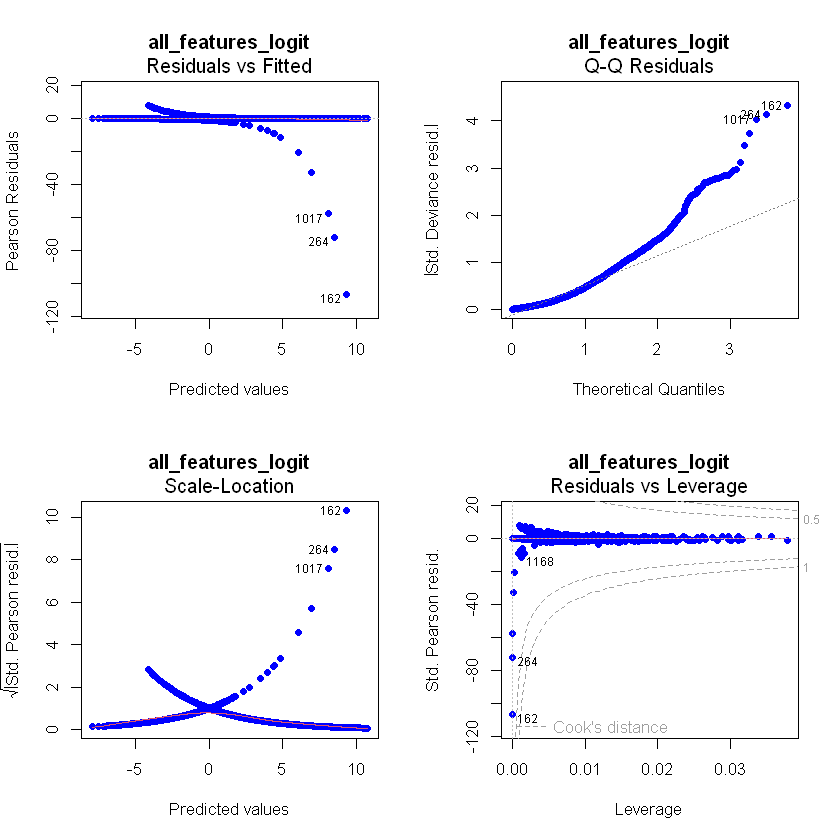

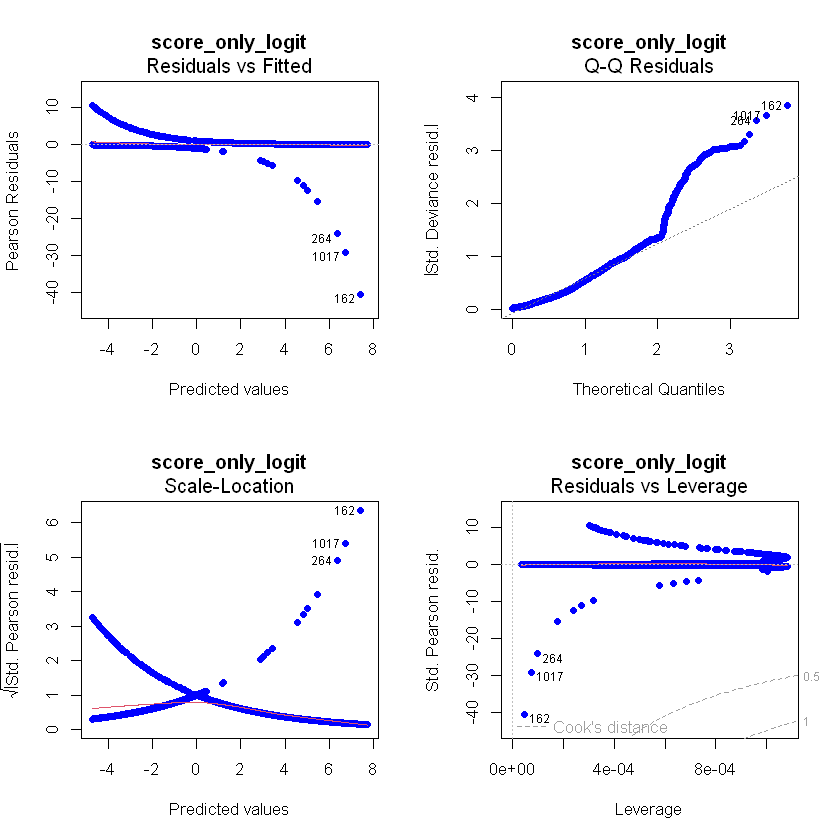

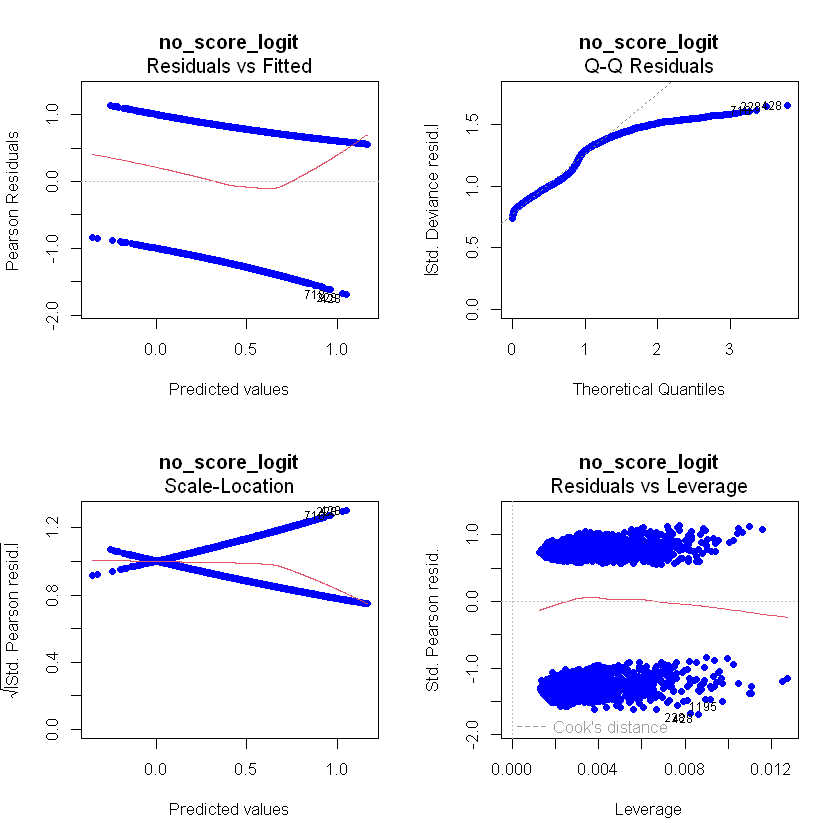

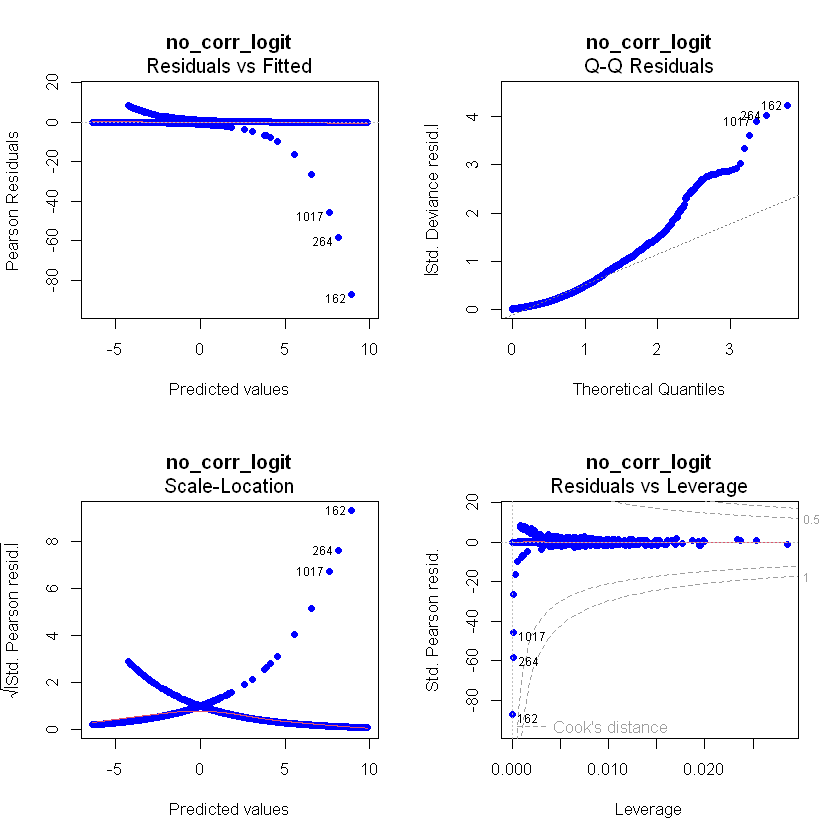

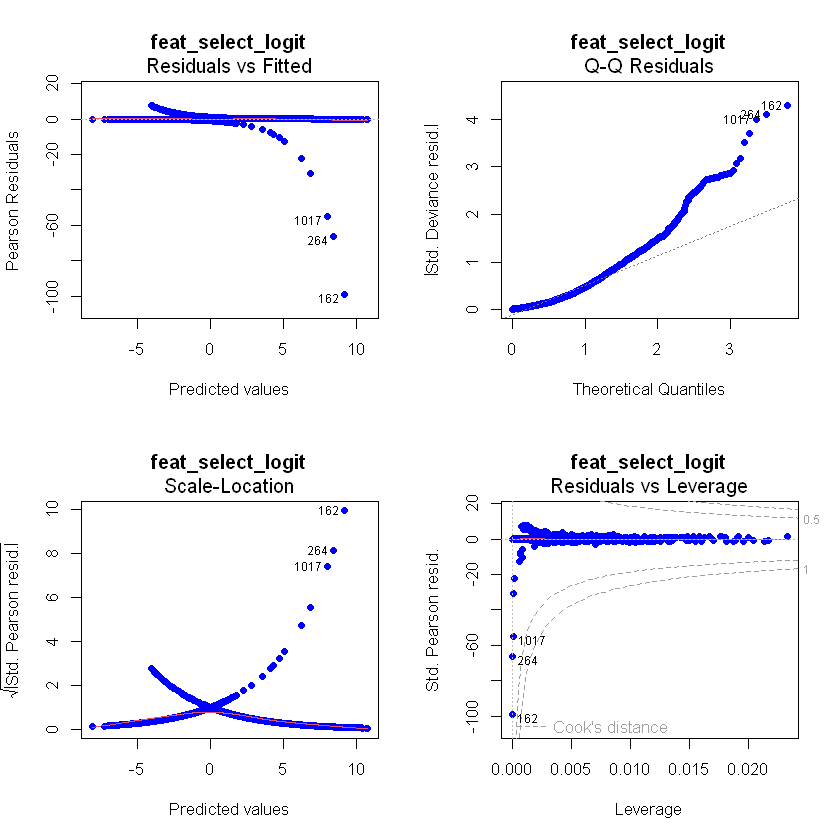

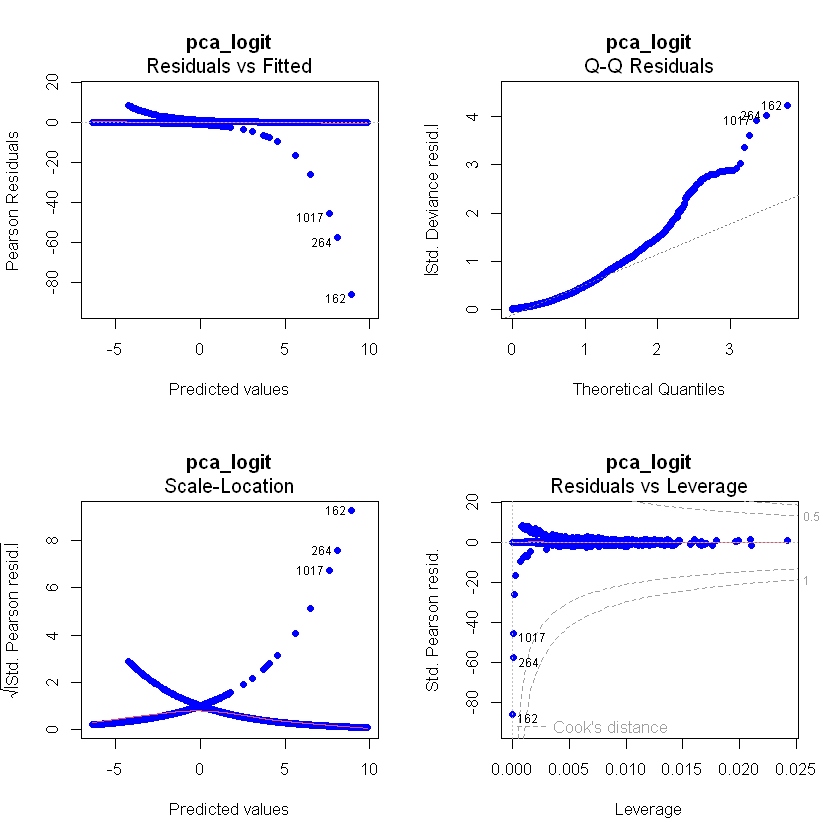

In [101]:
purrr::walk2(
  wf_fitted$fit,
  wf_fitted$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)

all_features_logit não é adequado para inferência, apesar do ótimo desempenho.
no_assets_logit reduz drasticamente a colinearidade sem perda preditiva.
feat_select_logit também melhora o VIF, mas menos que no_assets_logit.

In [102]:
library(dplyr)

model_summary <- metrics_table %>%
  select(
    wflow_id,
    accuracy,
    bal_accuracy,
    roc_auc,
    f1
  ) %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )

In [103]:
library(dplyr)

model_summary <- metrics_table %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )

In [104]:
model_summary

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,3.8004860,0.90594059,0.9397590,0.9014778,0.9425982,0.90370370,0.90504451,0.84488075,0.84488744,0.9226949,18.667257,4.225453
feat_select_logit,0.9279026,0.9245721,0.9764628,3.7926210,0.91089109,0.9382530,0.8997555,0.9453718,0.90528905,0.90864198,0.84709155,0.84713331,0.9244708,17.316120,6.456317
no_corr_logit,0.9307116,0.9278003,0.9736334,3.6179562,0.91584158,0.9397590,0.9024390,0.9483283,0.90909091,0.91312932,0.85312003,0.85318053,0.9277232,1.586206,1.226418
no_score_logit,0.6207865,0.5065162,0.6161838,0.8217493,0.03712871,0.9759036,0.4838710,0.6248795,0.06896552,0.04553734,0.01590783,0.03764666,0.1903524,17.106545,4.227158
pca_logit,0.9279026,0.9255413,0.9736148,3.6180796,0.91584158,0.9352410,0.8958838,0.9480916,0.90575275,0.91177920,0.84738667,0.84752151,0.9254904,NA,NA
score_only_logit,0.9213483,0.9173625,0.9651769,3.2187954,0.90099010,0.9337349,0.8921569,0.9393939,0.89655172,0.89920949,0.83311010,0.83313641,0.9172164,NA,NA


bom, no_score aponta que o cibil_score é importante
--- Modelos com melhores desempenhos geral
all_features_logit
feat_select_logit
no_assets_logit
- ROC AUC ~ 0.976
- F1 ~ 0.905–0.906
all_features_logit
-> Max VIF = 18.15 → forte colinearidade
feat_select_logit
-> Max VIF = 8.03 → redução significativa
no_assets_logit
-> melhor equilíbrio entre VIF (média menor) e performance

O PCA não aplica VIF e tem uma queda na performance

In [ ]:
library(tidymodels)
library(rstanarm)

In [ ]:
library(rstanarm)

fit_bayes <- stan_glm(
  status ~ . - luxury_assets_value - bank_asset_value,
  data = train_data,
  family = binomial(link = "logit"),
  prior = normal(0, 1),
  prior_intercept = normal(0, 5),
  chains = 4,
  iter = 2000,
  seed = 123
)


SAMPLING FOR MODEL 'bernoulli' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000249 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 2.49 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 3.048 seconds (Warm-up)
Chain 1:                2.644 seconds (Sampling)
Chain 1:                5.69

In [ ]:
post_prob <- posterior_linpred(
  fit_bayes,
  newdata = test_data,
  transform = TRUE
)

prob_mean <- colMeans(post_prob)

Instead of posterior_linpred(..., transform=TRUE) please call posterior_epred(), which provides equivalent functionality.



In [ ]:
pred_class <- ifelse(prob_mean > 0.5, "yes", "no") %>%
  factor(levels = levels(test_data$status))

In [ ]:
library(dplyr)

preds_bayes <- test_data %>%
  mutate(
    prob = prob_mean,
    class = factor(
      ifelse(prob >= 0.5, "1", "0"),
      levels = levels(loan_status)
    ),
    truth = status,
    wflow_id = "bayes_logit"
  )

preds_bayes <- preds_bayes %>%
  mutate(wflow_id = "bayes_logit")

In [ ]:
library(yardstick)
library(dplyr)

metrics_bayes <- preds_bayes %>%
  group_by(wflow_id) %>%
  summarise(

    # 📌 classificação geral
    accuracy = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    # 📌 ranking / separação
    roc_auc = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    # 📌 sensibilidade / especificidade
    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    # 📌 custo de erro (crédito)
    precision = precision_vec(truth, class),
    npv = npv_vec(truth, class),

    # 📌 equilíbrio
    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    # 📌 robustez estatística
    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    # 📌 equilíbrio sens/spec
    gmean = sqrt(
      sens_vec(truth, class) * spec_vec(truth, class)
    ),

    .groups = "drop"
  )

In [ ]:
table(preds_bayes$class)


  0   1 
396 665 

In [ ]:
library(car)

vif_bayes <- car::vif(fit_bayes)
vif_bayes

no_of_dependents             income_annum              loan_amount 
                1.012838                 8.527432                 7.471920 
               loan_term              cibil_score residential_assets_value 
                1.215696                 1.249258                 1.715511 
 commercial_assets_value `education_Not Graduate`        self_employed_Yes 
                1.622963                 1.008180                 1.003910

In [ ]:
vif_summary <- tibble(
  max_vif  = max(vif_bayes, na.rm = TRUE),
  mean_vif = mean(vif_bayes, na.rm = TRUE)
)

In [ ]:
metrics_bayes <- bind_cols(metrics_bayes, vif_summary)

In [ ]:
metrics_all <- bind_rows(
  model_summary,   
  metrics_bayes
)

metrics_all

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9293120,0.9240988,0.9762790,4.0469713,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520,18.147188,4.146099
feat_select_logit,0.9283695,0.9233413,0.9762979,4.0239070,0.90274314,0.9439394,0.9072682,0.9410876,0.90500000,0.90364453,0.84751192,0.84751875,0.9231115,8.031679,3.979695
no_assets_logit,0.9293120,0.9240988,0.9761845,4.0291824,0.90274314,0.9454545,0.9095477,0.9411765,0.90613267,0.90409590,0.84944461,0.84946001,0.9238520,8.585693,2.789998
no_score_logit,0.6145146,0.5042148,0.5974420,0.8170664,0.05236908,0.9560606,0.4200000,0.6241345,0.09312639,0.06348247,0.01017766,0.01928834,0.2237588,17.041102,4.216524
pca_logit,0.9227144,0.9163493,0.9736001,3.8883426,0.89027431,0.9424242,0.9037975,0.9339339,0.89698492,0.89294647,0.83515043,0.83521119,0.9159782,NA,NA
score_only_logit,0.9274270,0.9235623,0.9669104,3.4150647,0.90773067,0.9393939,0.9009901,0.9436834,0.90434783,0.90637450,0.84588292,0.84589817,0.9234266,NA,NA
bayes_logit,0.9293120,0.9236095,0.9762450,3.9125059,0.90024938,0.9469697,0.9116162,0.9398496,0.90589711,0.90250000,0.84929691,0.84933978,0.9233141,8.527432,2.758634


Warning message:
"The following arguments were unrecognized and ignored: pch, col, main"


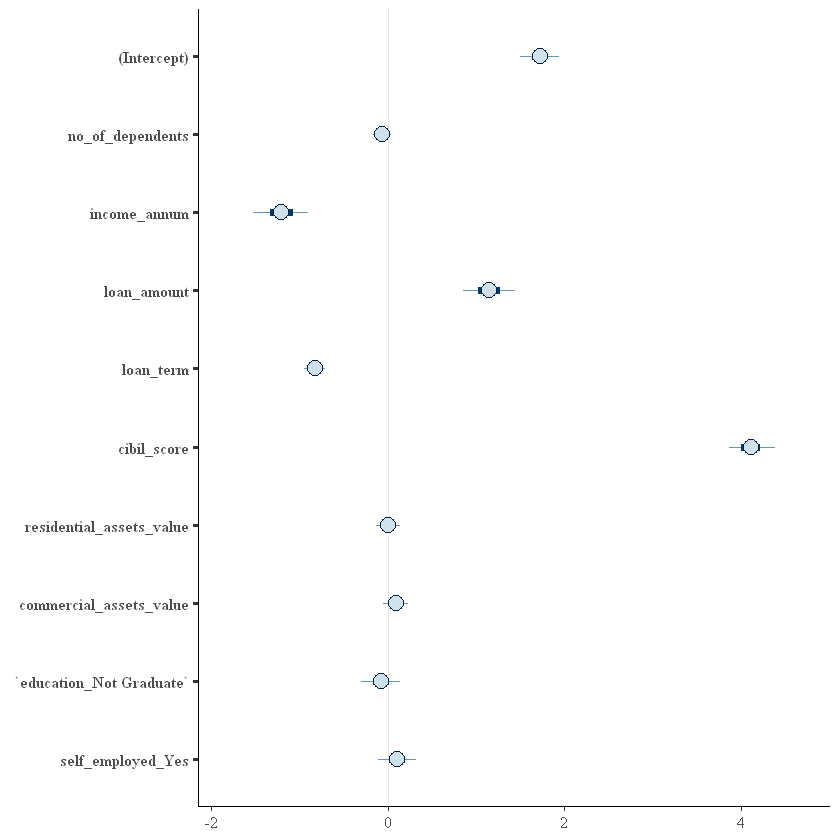

In [ ]:
par(mfrow = c(2, 2))

plot(
  fit_bayes,
  pch = 19,
  col = "blue",
  main = "Bayesian Logistic Regression"
)

par(mfrow = c(1, 1))  # reset layout

Warning message:
"The following arguments were unrecognized and ignored: type"


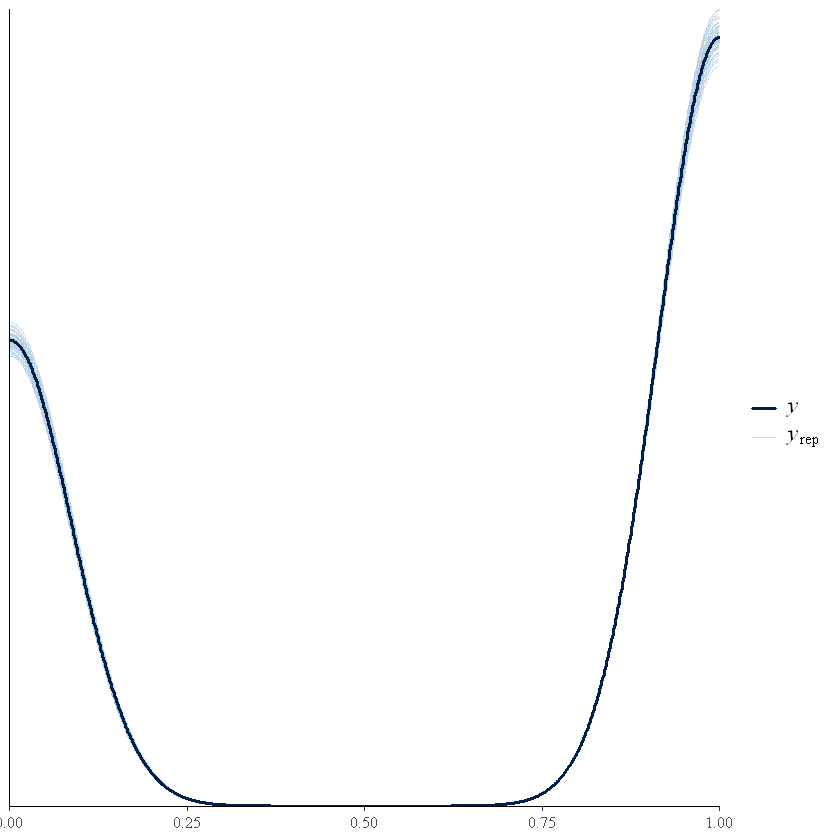

In [ ]:
library(bayesplot)

pp_check(fit_bayes, type = "dens_overlay")